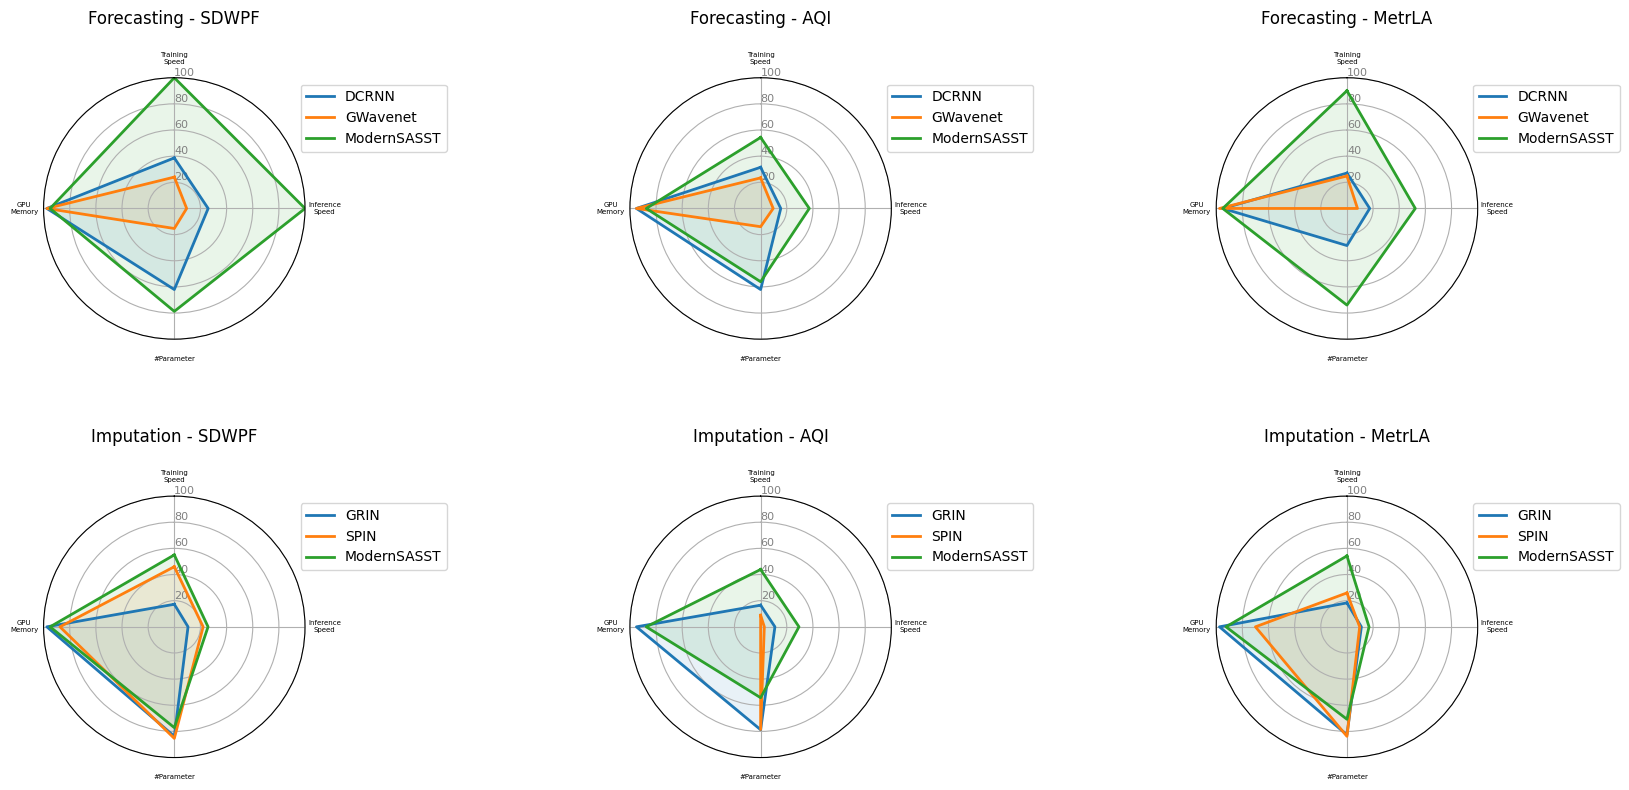

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from math import pi
from typing import Dict, List, Tuple, Any
from dataclasses import dataclass
from enum import Enum


@dataclass
class MethodPerformance:
    """方法性能数据类"""
    param: int  # 参数量(K)
    gpu: int    # GPU内存(G)
    training: float  # 训练速度(batch/s)
    testing: float   # 测试速度(batch/s)


class TaskType(Enum):
    """任务类型枚举"""
    FORECASTING = "Forecasting"
    IMPUTATION = "Imputation"


class PerformanceVisualizer:
    """性能可视化类"""
    
    def __init__(self):
        self.forecasting_data = self._init_forecasting_data()
        self.imputation_data = self._init_imputation_data()
        self.datasets = ['SDWPF', 'AQI', 'MetrLA']
        self.colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
        self.categories = ['Training\nSpeed', 'Inference\nSpeed', '#Parameter', 'GPU\nMemory']
        
    def _init_forecasting_data(self) -> Dict[str, Dict[str, MethodPerformance]]:
        """初始化预测任务数据"""
        return {
            "SDWPF": {
                "DCRNN": MethodPerformance(166, 1, 18.31, 43.24),
                "GWavenet": MethodPerformance(370, 1, 11.36, 15.76),
                "ModernSASST": MethodPerformance(93, 2, 47.35, 167.01)
            },
            "AQI": {
                "DCRNN": MethodPerformance(166, 2, 14.91, 25.70),
                "GWavenet": MethodPerformance(376, 2, 11.08, 16.03),
                "ModernSASST": MethodPerformance(192, 5, 25.72, 62.18)
            },
            "MetrLA": {
                "DCRNN": MethodPerformance(313, 2, 12.82, 29.07),
                "GWavenet": MethodPerformance(437, 1, 11.77, 13.45),
                "ModernSASST": MethodPerformance(114, 2, 42.65, 87.28)
            }
        }
    
    def _init_imputation_data(self) -> Dict[str, Dict[str, MethodPerformance]]:
        """初始化插补任务数据"""
        return {
            "SDWPF": {
                "GRIN": MethodPerformance(71, 1, 8.17, 17.54),
                "SPIN": MethodPerformance(64, 5, 21.77, 36.82),
                "ModernSASST": MethodPerformance(100, 2, 26.05, 43.12)
            },
            "AQI": {
                "GRIN": MethodPerformance(93, 2, 7.84, 18.26),
                "SPIN": MethodPerformance(94, 40, 4.20, 4.71),
                "ModernSASST": MethodPerformance(200, 5, 20.77, 48.99)
            },
            "MetrLA": {
                "GRIN": MethodPerformance(76, 1, 8.67, 18.41),
                "SPIN": MethodPerformance(71, 12, 12.28, 16.26),
                "ModernSASST": MethodPerformance(128, 3, 25.69, 28.23)
            }
        }
    
    def _get_normalization_bounds(self) -> Tuple[float, float, float, float]:
        """获取所有数据的归一化边界"""
        all_performances = []
        
        # 收集所有性能数据
        for data_dict in [self.forecasting_data, self.imputation_data]:
            for dataset in data_dict.values():
                for perf in dataset.values():
                    all_performances.append(perf)
        
        # 计算各维度的最大值
        max_training = max(p.training for p in all_performances)
        max_testing = max(p.testing for p in all_performances)
        max_param = max(p.param for p in all_performances)
        max_gpu = max(p.gpu for p in all_performances)
        
        return max_training, max_testing, max_param, max_gpu
    
    def normalize_data(self, dataset_data: Dict[str, MethodPerformance]) -> Dict[str, List[float]]:
        """
        归一化数据到0-100范围
        
        Args:
            dataset_data: 某个数据集的方法性能数据
            
        Returns:
            归一化后的数据字典
        """
        max_training, max_testing, max_param, max_gpu = self._get_normalization_bounds()
        
        normalized = {}
        for method, perf in dataset_data.items():
            # 参数量和GPU内存：越少越好（反向归一化）
            param_eff = 100 * (1 - perf.param / max_param)
            gpu_eff = 100 * (1 - perf.gpu / max_gpu)
            
            # 训练和测试速度：越快越好（正向归一化）
            training_speed = 100 * perf.training / max_training
            testing_speed = 100 * perf.testing / max_testing
            
            normalized[method] = [training_speed, testing_speed, param_eff, gpu_eff]
        
        return normalized
    
    def create_radar_chart(self, ax: plt.Axes, data: Dict[str, List[float]], 
                          title: str, colors: List[str]) -> None:
        """
        创建单个雷达图
        
        Args:
            ax: matplotlib轴对象
            data: 归一化后的数据
            title: 图表标题
            colors: 颜色列表
        """
        N = len(self.categories)
        
        # 计算每个类别的角度
        angles = [n / float(N) * 2 * pi for n in range(N)]
        angles += angles[:1]
        
        # 设置极坐标图
        ax.set_theta_offset(pi / 2)
        ax.set_theta_direction(-1)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(self.categories, fontsize=5, fontweight='normal')
        ax.set_rlabel_position(0)
        ax.set_yticks([20, 40, 60, 80, 100])
        ax.set_yticklabels(["20", "40", "60", "80", "100"], color="grey", size=8)
        ax.set_ylim(0, 100)
        ax.grid(True)
        
        # 绘制每个方法的数据
        for i, (method, values) in enumerate(data.items()):
            values_plot = values + [values[0]]  # 闭合图形
            ax.plot(angles, values_plot, linewidth=2, linestyle='solid', 
                    label=method, color=colors[i])
            ax.fill(angles, values_plot, color=colors[i], alpha=0.1)
        
        ax.set_title(title, size=12, fontweight='normal', pad=20)
        ax.legend(loc='upper right', bbox_to_anchor=(1.57, 1.0))
    
    def plot_comparison(self) -> None:
        """绘制完整的对比图"""
        # 调整图像尺寸：增加宽度，减少高度
        fig = plt.figure(figsize=(18, 8))
        # fig.suptitle('Performance Comparison: Forecasting vs Imputation', 
        #             fontsize=16, fontweight='bold')
        
        # 绘制预测任务图表（上排）
        for i, dataset in enumerate(self.datasets):
            ax = fig.add_subplot(2, 3, i+1, projection='polar')
            data = self.normalize_data(self.forecasting_data[dataset])
            self.create_radar_chart(ax, data, f'Forecasting - {dataset}', self.colors)
        
        # 绘制插补任务图表（下排）
        for i, dataset in enumerate(self.datasets):
            ax = fig.add_subplot(2, 3, i+4, projection='polar')
            data = self.normalize_data(self.imputation_data[dataset])
            self.create_radar_chart(ax, data, f'Imputation - {dataset}', self.colors)
        
        # 调整子图间距：增加水平和垂直间距
        plt.tight_layout()
        plt.subplots_adjust(hspace=0.6, wspace=0.15)
        plt.savefig('performance_comparison.pdf', bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        plt.show()
    
    def print_normalized_values(self) -> None:
        """打印归一化后的数值，便于参考"""
        print("Forecasting Data (Normalized 0-100):")
        for dataset in self.datasets:
            print(f"\n{dataset}:")
            data = self.normalize_data(self.forecasting_data[dataset])
            for method, values in data.items():
                print(f"  {method}: Training={values[0]:.1f}, Testing={values[1]:.1f}, "
                      f"ParamEff={values[2]:.1f}, MemEff={values[3]:.1f}")
        
        print("\nImputation Data (Normalized 0-100):")
        for dataset in self.datasets:
            print(f"\n{dataset}:")
            data = self.normalize_data(self.imputation_data[dataset])
            for method, values in data.items():
                print(f"  {method}: Training={values[0]:.1f}, Testing={values[1]:.1f}, "
                      f"ParamEff={values[2]:.1f}, MemEff={values[3]:.1f}")
    
    def export_to_dataframe(self, task_type: TaskType) -> pd.DataFrame:
        """
        导出数据到DataFrame格式
        
        Args:
            task_type: 任务类型
            
        Returns:
            包含性能数据的DataFrame
        """
        data_dict = self.forecasting_data if task_type == TaskType.FORECASTING else self.imputation_data
        
        records = []
        for dataset, methods in data_dict.items():
            for method, perf in methods.items():
                records.append({
                    'Dataset': dataset,
                    'Method': method,
                    'Parameters (K)': perf.param,
                    'GPU Memory (G)': perf.gpu,
                    'Training Speed (batch/s)': perf.training,
                    'Testing Speed (batch/s)': perf.testing
                })
        
        return pd.DataFrame(records)


def main():
    """主函数"""
    visualizer = PerformanceVisualizer()
    
    # 绘制对比图
    visualizer.plot_comparison()
    
    # 打印归一化数值
    # visualizer.print_normalized_values()
    
    # 导出到DataFrame（可选）
    # df_forecast = visualizer.export_to_dataframe(TaskType.FORECASTING)
    # df_imputation = visualizer.export_to_dataframe(TaskType.IMPUTATION)
    # print("\nForecasting DataFrame:")
    # print(df_forecast)
    # print("\nImputation DataFrame:")
    # print(df_imputation)


if __name__ == "__main__":
    main()